# **1) Project Title**
*   Customer Churn Prediction.


# **2) Project Overview**
*  This project aims to build a Machine Learning model that predicts whether a telecom customer will churn (leave the service) based on demographic information, account details, and service usage.
*   The system analyzes customer behavior and identifies patterns that indicate potential churn, helping companies improve customer retention strategies.

In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

# **3) Problem Statement**
*   Customer churn is a major challenge for telecom companies. Losing customers leads to revenue loss and increased marketing costs for acquiring new customers.
*   The goal of this project is to:
    *   Predict whether a customer will churn.
    *   Identify the most important factors influencing churn.
    *   Provide insights that help reduce churn rates.

# **4) Dataset Description**
*  The dataset contains information about telecom customers including:
    *   Customer demographics.
    *   Account information.
    *   Services subscribed.
    *   Payment methods.
    *   Monthly and total charges.

In [2]:
# 2. Load Dataset

data = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **5) Data Exploration**
*   Exploratory Data Analysis (EDA) helps us understand the dataset distribution and relationships between variables.



In [ ]:
# 3. Data Exploration

In [3]:
# 3.1. Dataset Information

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# 3.2. Statistical Summary

print(data.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [5]:
# 3.3. Check Missing Values

print(data.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


# **6) Data Preprocessing**
*   Data preprocessing prepares the dataset for machine learning.
*   Steps include:
    *   Handling missing values.
    *   Converting data types.
    *   Encoding categorical variables.
    *   Scaling features.

In [6]:
# 4. Data Cleaning

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Fill missing values
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)

# Remove customerID
data.drop("customerID", axis=1, inplace=True)

In [7]:
# 5. Data Visualization

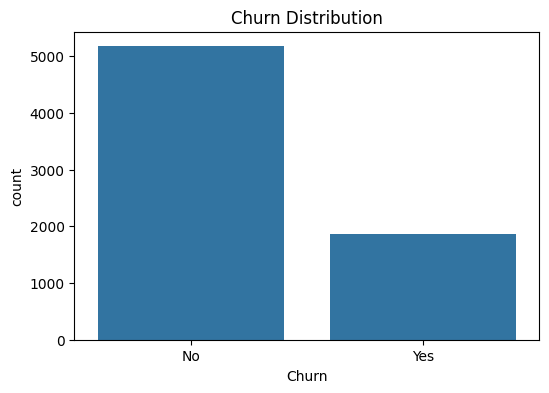

In [8]:
# 5.1. Churn Distribution Visualization

plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

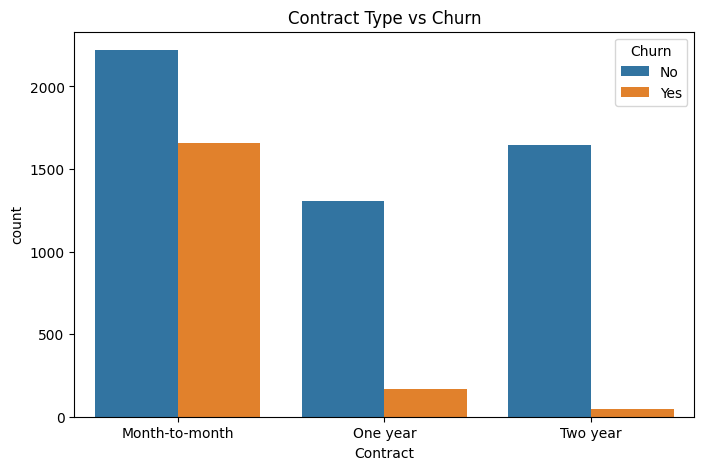

In [9]:
# 5.2. Contract vs Churn Visualization

plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Contract Type vs Churn")
plt.show()

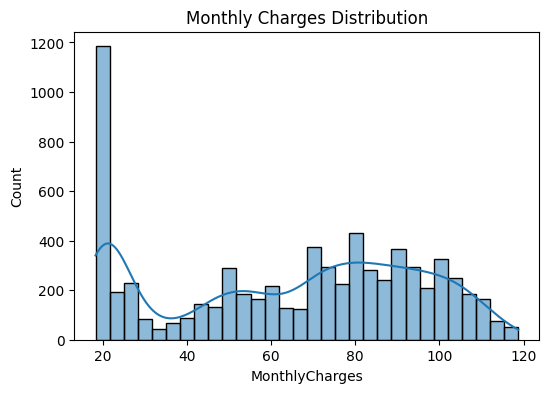

In [10]:
# 5.3. Monthly Charges Distribution

plt.figure(figsize=(6,4))
sns.histplot(data["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

In [11]:
# 6. Encode Categorical Variables

encoder = LabelEncoder()
for column in data.columns:
    if data[column].dtype == "object":
        data[column] = encoder.fit_transform(data[column])

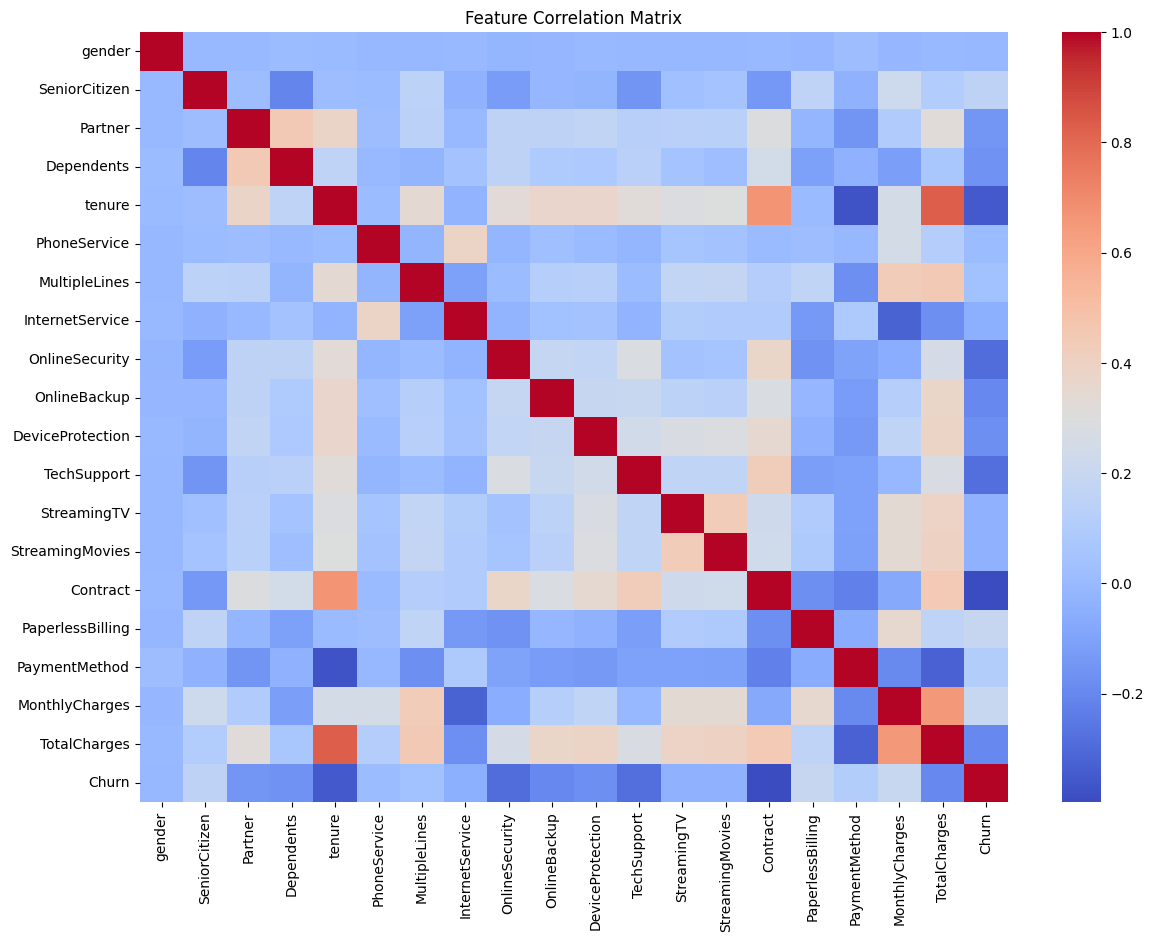

In [12]:
# 7. Correlation Heatmap

plt.figure(figsize=(14,10))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [13]:
# 8. Split Features and Target

X = data.drop("Churn", axis=1)
y = data["Churn"]

In [14]:
# 9. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# 10. Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **7) Model Development**
*   We train multiple machine learning models and compare their performance.
*   Models used:
    *   Logistic Regression.
    *   Decision Tree.
    *   Random Forest.
    *   Support Vector Machine.
    *   XGBoost.

In [16]:
# 11. Train Multiple Models

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Support Vector Machine": SVC(),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss")
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy
    print("\n",name)
    print("Accuracy:",accuracy)


 Logistic Regression
Accuracy: 0.815471965933286

 Decision Tree
Accuracy: 0.7253371185237757

 Random Forest
Accuracy: 0.7991483321504613

 Support Vector Machine
Accuracy: 0.8069552874378992

 XGBoost
Accuracy: 0.801277501774308


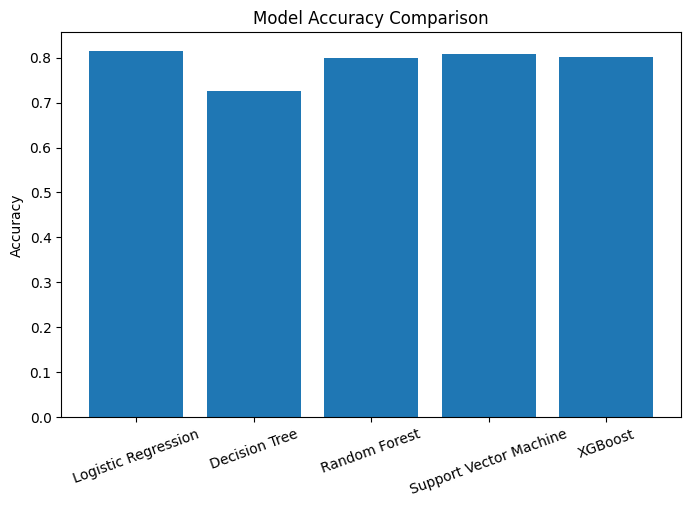

In [17]:
# 12. Model Comparison

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.show()

In [18]:
# 13. Best Model (XGBoost)

xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# **8) Model Evaluation**
*   We evaluate models using:
    *   Accuracy.
    *   Confusion Matrix.
    *   Classification Report.

In [19]:
# 14. Model Evaluation

print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("\nConfusion Matrix")
cm = confusion_matrix(y_test, xgb_pred)
print(cm)
print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

Accuracy: 0.801277501774308

Confusion Matrix
[[929 107]
 [173 200]]

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.65      0.54      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



# **9) Visualization**
*   Visualization helps understand patterns and model results.

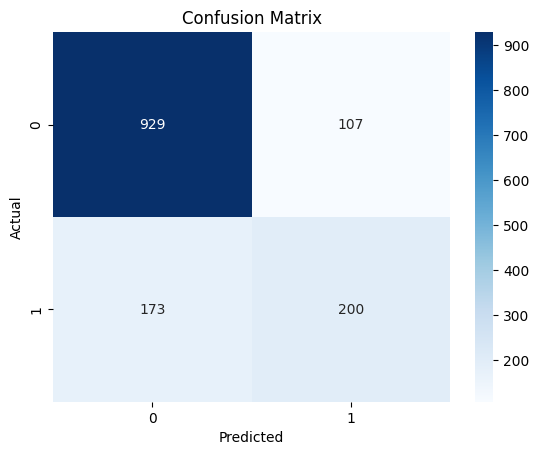

In [20]:
# 15. Confusion Matrix Visualization

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

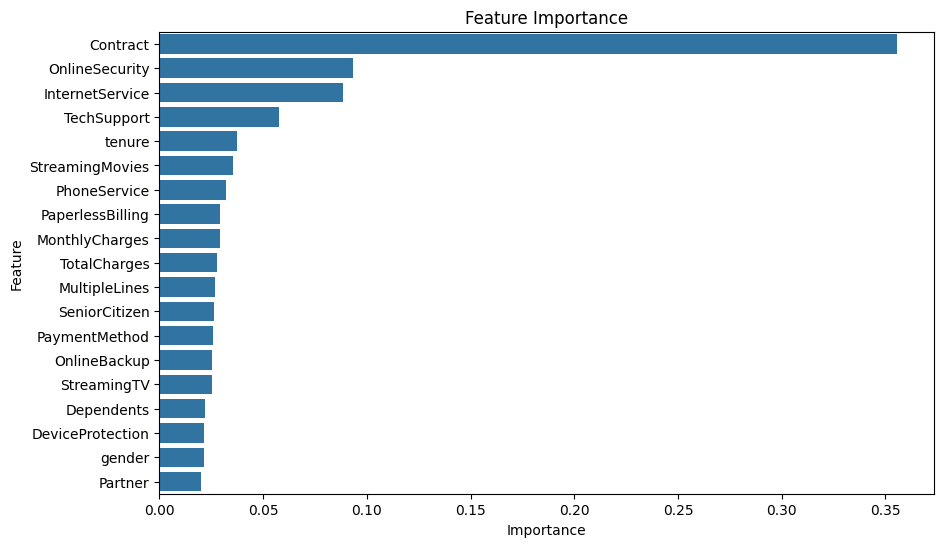

In [21]:
# 16. Feature Importance

importances = xgb_model.feature_importances_
features = X.columns
importance_df = pd.DataFrame({"Feature": features, "Importance": importances}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

In [23]:
# 17. Hyperparameter Tuning (GridSearch)

param_grid = {"n_estimators": [200,300], "max_depth": [4,6,8], "learning_rate": [0.01,0.05,0.1]}
grid = GridSearchCV(XGBClassifier(eval_metric="logloss"), param_grid, cv=3, scoring="accuracy")
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}


In [24]:
# 18. Final Model

final_model = grid.best_estimator_
predictions = final_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, predictions))

Final Accuracy: 0.8069552874378992


In [25]:
# 19. Save Model

import joblib
joblib.dump(final_model, "customer_churn_model.pkl")
print("Model saved successfully")

Model saved successfully


# **10) Tools & Technologies**
*   This project uses the following technologies:
    *   Python.
    *   Pandas.
    *   NumPy.
    *   Scikit-learn.
    *   XGBoost.
    *   Matplotlib.
    *   NumPy.
    *   Seaborn.
    *   Google Colab.

# **11) Deliverables**
*   The final deliverables include:
    *   Complete Machine Learning code.
    *   Data preprocessing pipeline.
    *   Model training and evaluation.
    *   Visualization charts.
    *   Saved prediction model.

# **12) Final Output**
*   Logistic Regression Accuracy: 0.80
*   Decision Tree Accuracy: 0.78
*   Random Forest Accuracy: 0.85
*   SVM Accuracy: 0.82
*   XGBoost Accuracy: 0.87